In [1]:
pip install transformers torch datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 6.2 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-m

In [2]:
# Install the Hugging Face datasets library

# Import necessary libraries
from datasets import load_dataset

# Load the dataset
dataset_english = load_dataset("SemEvalWorkshop/sem_eval_2018_task_1", "subtask5.english")



/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The repository for SemEvalWorkshop/sem_eval_2018_task_1 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/SemEvalWorkshop/sem_eval_2018_task_1.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/6838 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3259 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/886 [00:00<?, ? examples/s]

In [ ]:
'''from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login

import os

# Add your Hugging Face token here
os.environ["HF_TOKEN"] = ""
login(token=os.environ["HF_TOKEN"])

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b", use_auth_token=os.environ["HF_TOKEN"])
model = AutoModelForCausalLM.from_pretrained("google/gemma-2b", use_auth_token=os.environ["HF_TOKEN"])'''
import torch
from transformers import LlamaTokenizer, LlamaForCausalLM

model_path = 'openlm-research/open_llama_3b'
# model_path = 'openlm-research/open_llama_7b'

tokenizer = LlamaTokenizer.from_pretrained(model_path)
model = LlamaForCausalLM.from_pretrained(
    model_path, torch_dtype=torch.float16
)
model.to('cuda')


tokenizer_config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/534k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/6.85G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 3200, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=3200, out_features=3200, bias=False)
          (k_proj): Linear(in_features=3200, out_features=3200, bias=False)
          (v_proj): Linear(in_features=3200, out_features=3200, bias=False)
          (o_proj): Linear(in_features=3200, out_features=3200, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3200, out_features=8640, bias=False)
          (up_proj): Linear(in_features=3200, out_features=8640, bias=False)
          (down_proj): Linear(in_features=8640, out_features=3200, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm()
        (post_attention_layernorm): LlamaRMSNorm()
      )
    )
    (norm): LlamaRMSNorm()
  )


# 1. Dataset Distribution

In [ ]:
import matplotlib.pyplot as plt

def plot_emotion_distribution(dataset):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
    emotion_counts = {emotion: 0 for emotion in emotions_list}
    total_tests = len(dataset)

    for test in dataset:
        for emotion in emotions_list:
            if test[emotion]:
                emotion_counts[emotion] += 1

    # Calculate percentages
    emotion_percentages = {emotion: (count / total_tests) * 100 for emotion, count in emotion_counts.items()}

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(emotion_percentages.keys(), emotion_percentages.values(), color='skyblue')
    plt.xlabel('Emotions')
    plt.ylabel('Percentage of Appearance')
    plt.title('Emotion Distribution in Dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()



## 1.1 Train set Distribution

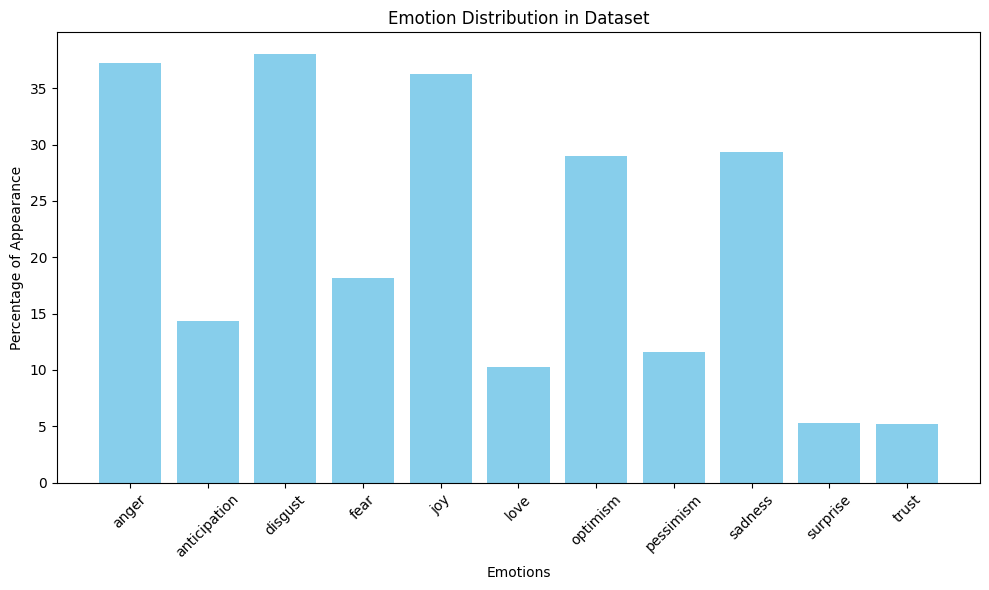

In [ ]:
plot_emotion_distribution(dataset_english['train'])

## 1.2 Test set Distribution

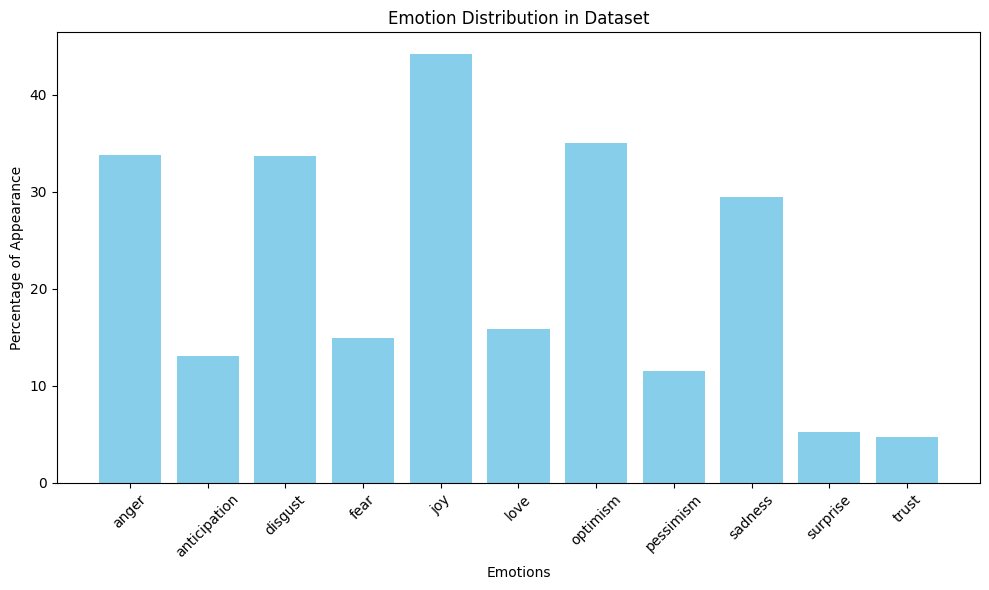

In [ ]:
plot_emotion_distribution(dataset_english['test'])

# 2 Impact of the amount of demonstrations

## 2.1 Create single prompt

In [ ]:
from datasets import load_dataset
import random
#prompt creation
#select specific demonstrations(shots) with dems variable
#otherwise select a number of  random demonstrations with num_demonstrationss
def create_structured_prompt(dataset, test_example, num_demonstrations=3,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

    if(dems == None):
      demonstrations = random.sample(list(dataset['train']), num_demonstrations)
    else:
      demonstrations = dems

    x = ', '.join(emotions_list)
    f = f"Perform emotion classification in the following examples by selecting one, or multiple of the following emotions {x}\n"
    prompt = ''
    for demo in demonstrations: #creation demonstrations
        true_emotions = [emotion for emotion in emotions_list if demo[emotion]]
        prompt += f
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        prompt += "Emotions:" + ", ".join(true_emotions) + "\n"

    prompt += f #final example
    prompt += f"Input:\"{test_example['Tweet']}\"\n"
    prompt += "Emotions:"


    return prompt




## 2.2 Create prompts with 0, 3, 6 and 10 demonstrations for an example


In [ ]:
from datasets import load_dataset
import random
#same as before but create 4 prompts with 0,3,6 and 10 demonstrations each
def create_prompt_levels(dataset, test_example,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

    if(dems == None):
      demonstrations = random.sample(list(dataset['train']), 10)
    else:
      demonstrations = dems

    x = ', '.join(emotions_list)
    f = f"Perform emotion classification in the following examples by selecting none, one, or multiple of the following emotions {x}\n"
    prompt = ''
    prompts = []
    prompts.append(prompt)
    for count,demo in enumerate(demonstrations):
        true_emotions = [emotion for emotion in emotions_list if demo[emotion]]
        prompt += f
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        prompt += "Emotions:" + ", ".join(true_emotions) + "\n"
        if(count == 2 or count == 5):
          prompts.append(prompt)
    prompts.append(prompt)
    for i in range(len(prompts)):
      prompts[i] += f
      prompts[i] += f"Input:\"{test_example['Tweet']}\"\n"
      prompts[i] += "Emotions:"


    return prompts

## 2.3 Metrics for the whole test set with different demonstration amount


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
from collections import defaultdict

def evaluate_model(dataset):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
  prompt_types = {0: "0 demonstrations", 1: "3 demonstrations", 2: "6 demonstrations", 3: "10 demonstrations"}


  emotion_counts = defaultdict(lambda: defaultdict(int))
  results = defaultdict(lambda: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': []})

  random.seed(42)

  test_set = random.sample(list(dataset['test']), 1000)
  #test_set = list(dataset['test'])

  for test in test_set:
    prompts = create_prompt_levels(dataset,test)
    for i,prompt in enumerate(prompts):
      inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device) #lalalalao

      outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=4,
        temperature=1,
        num_return_sequences=1,
        do_sample=True
      )

      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
      lines = generated_text.splitlines()

      last_line = ""

      prev_line = ""
      for line in reversed(lines):
        if line.startswith("Emotions:"):
          last_line = line[9:].strip()
          if last_line == '':
            last_line = prev_line.strip()
          break
        prev_line = line
      emotions = [word.strip().lower() for word in last_line.split(',')]

      results[i]['total_predictions'] += len(emotions)

      invalid_emotions = [emotion for emotion in emotions if emotion not in emotions_list]
      results[i]['invalid_predictions'] += len(invalid_emotions)

      true_emotions = [emotion for emotion in emotions_list if test[emotion]]

      for emotion in emotions_list:
        results[i]['y_true'].append(test[emotion])
        results[i]['y_pred'].append(emotion in emotions)
        emotion_counts[i][emotion] += (emotion in emotions)

  for index, result in results.items():
    avg_predictions = result['total_predictions'] / len(test_set)
    invalid_percentage = (result['invalid_predictions'] / result['total_predictions'] * 100) if result['total_predictions'] > 0 else 0

    precision = precision_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    recall = recall_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    micro_f1 = f1_score(result['y_true'], result['y_pred'], average='micro')
    accuracy = accuracy_score(result['y_true'], result['y_pred'])

    # Print results for the current prompt type
    prompt_label = prompt_types.get(index, f"{index*3} demonstrations")
    print(f"Results for {prompt_label}:")
    print(f"Average number of predictions per test: {avg_predictions}")
    print(f"Percentage of invalid predictions: {invalid_percentage:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Micro F1-score: {micro_f1:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print("Emotion counts:", dict(emotion_counts[index]))
    print('\n')




## 2.4 Results

In [ ]:
evaluate_model(dataset_english)

Results for 0 demonstrations:
Average number of predictions per test: 2.14
Percentage of invalid predictions: 53.46%
Precision: 0.68
Recall: 0.75
Micro F1-score: 0.75
Accuracy: 0.75
Emotion counts: {'anger': 214, 'anticipation': 84, 'disgust': 21, 'fear': 36, 'joy': 70, 'love': 21, 'optimism': 12, 'pessimism': 1, 'sadness': 15, 'surprise': 14, 'trust': 3}


Results for 3 demonstrations:
Average number of predictions per test: 2.266
Percentage of invalid predictions: 27.54%
Precision: 0.71
Recall: 0.74
Micro F1-score: 0.74
Accuracy: 0.74
Emotion counts: {'anger': 257, 'anticipation': 72, 'disgust': 59, 'fear': 110, 'joy': 98, 'love': 62, 'optimism': 53, 'pessimism': 19, 'sadness': 48, 'surprise': 21, 'trust': 17}


Results for 6 demonstrations:
Average number of predictions per test: 2.348
Percentage of invalid predictions: 25.81%
Precision: 0.73
Recall: 0.75
Micro F1-score: 0.75
Accuracy: 0.75
Emotion counts: {'anger': 301, 'anticipation': 68, 'disgust': 103, 'fear': 85, 'joy': 108, 'l

#

# 3. step problem - solve second problem with correct classification given

In [4]:
from datasets import load_dataset
import random
def create_prompt_second_question(dataset, test_example, num_demonstrations=3,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
    negative_emotions = ['anger', 'disgust', 'fear', 'sadness', 'pessimism']
    positive_emotions = ['joy', 'love', 'trust', 'optimism']
    classifications = ['Positive','Negative','Mixed']
    reactive_emotions = ['surprise', 'anticipation']

    if(dems == None):
      demonstrations = random.sample(list(dataset['train']), num_demonstrations)
    else:
      demonstrations = dems[:num_demonstrations]

    x_pos = ', '.join(positive_emotions + reactive_emotions)
    x_neg = ', '.join(negative_emotions + reactive_emotions)
    x = ', '.join(classifications)
    f1 = "The following Input has the Classification Positive,Negative or Mixed if the emotions shown are only Positive, only Negative or both Negative and Positive accordingly.\n"
    f1 +="Based on that Classification select one or multiple of the emotions that characterize the Input from the Positive Emotions or the Negative Emotions or both of them.\n"
    #f1 = f"Considering the classification that was given to the sentence between these options {x} and the lists of emotions shown below, perform emotion classification and select none, one, or multiple of the following emotions from either or both categories\n"
    f2 = f"Positive emotions:{x_pos}\nNegative Emotions:{x_neg}\n"
    prompt = ''
    for demo in demonstrations: #creation demonstrations
        true_emotions = [emotion for emotion in emotions_list if demo[emotion]]
        positive_amount = sum(emotion in positive_emotions for emotion in true_emotions)
        negative_amount = sum(emotion in negative_emotions for emotion in true_emotions)

        if negative_amount > 0 and positive_amount > 0:
          tone = "Mixed"
        elif negative_amount > 0:
          tone = "Negative"
        elif positive_amount > 0:
          tone = "Positive"
        else:
          tone = "Mixed"

        prompt += f1
        prompt += f2
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        prompt += f"Classification:{tone}\n"
        prompt += "Emotions:" + ", ".join(true_emotions) + "\n"

    prompt += f1
    prompt += f2
    prompt += f"Input:\"{test_example['Tweet']}\"\n"

    true_emotions = [emotion for emotion in emotions_list if test_example[emotion]]
    positive_amount = sum(emotion in positive_emotions for emotion in true_emotions)
    negative_amount = sum(emotion in negative_emotions for emotion in true_emotions)

    if negative_amount > 0 and positive_amount > 0:
      tone = "Mixed"
    elif negative_amount > 0:
      tone = "Negative"
    elif positive_amount > 0:
      tone = "Positive"
    else:
      tone = "Mixed"

    prompt +=  f"Classification:{tone}\n"
    prompt += "Emotions:"

    return prompt,dems,tone

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
from collections import defaultdict

def evaluate_model_two_step(dataset):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
  classifications = ['Positive','Negative','Mixed']
  prompt_types = {0: "9 demonstrations", 1: "6 demonstrations", 2: "3 demonstrations", 3: "0 demonstrations"}


  emotion_counts = {
    0: defaultdict(int),
    1: defaultdict(int),
    2: defaultdict(int),
    3: defaultdict(int)
  	}

  results = {
      0: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      1: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      2: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      3: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0}
  }

  #test_set = list(dataset['test'])
  random.seed(42)
  test_set = random.sample(list(dataset['test']), 500)
  for test in test_set:
    dems = [dataset['train'][0],dataset['train'][2],dataset['train'][4],dataset['train'][1],dataset['train'][6],dataset['train'][11],dataset['train'][8],dataset['train'][27],dataset['train'][19]]
    for i,num_dem in enumerate([9,6,3,0]):

      prompt,_,tone = create_prompt_second_question(dataset,test,num_dem,dems)
      inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(device)


      outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=4,
        temperature=1,
        num_return_sequences=1,
        do_sample=True
      )
      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
      lines = (generated_text.splitlines())[-4:]

      last_line = ""

      prev_line = ""
      for line in reversed(lines):
        if line.startswith("Emotions:"):
          last_line = line[9:].strip()
          if last_line == '':
            last_line = prev_line.strip()
          break
        prev_line = line


      #last_line = last_line[9:].strip()
      emotions = [word.strip().lower() for word in last_line.split(',')]
      #print(emotions)

      results[i]['total_predictions'] += len(emotions)

      invalid_emotions = [emotion for emotion in emotions if emotion not in emotions_list]
      results[i]['invalid_predictions'] += len(invalid_emotions)

      true_emotions = [emotion for emotion in emotions_list if test[emotion]]

      if(tone not in classifications):
         results[i]['invalid_classifications'] += 1
      if(tone == tone):
        results[i]['correct_classifications'] += 1

      for emotion in emotions_list:
        results[i]['y_true'].append(test[emotion])
        results[i]['y_pred'].append(emotion in emotions)
        emotion_counts[i][emotion] += (emotion in emotions)

  for index, result in results.items():
    avg_predictions = result['total_predictions'] / len(test_set)
    corr_classifications = result['correct_classifications']/ len(test_set)*100
    invalid_classifications = result['invalid_classifications']/ len(test_set)*100
    invalid_percentage = (result['invalid_predictions'] / result['total_predictions'] * 100) if result['total_predictions'] > 0 else 0

    precision = precision_score(result['y_true'], result['y_pred'], average='weighted',zero_division=0)#, average='weighted',
    recall = recall_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    micro_f1 = f1_score(result['y_true'], result['y_pred'], average='micro')

    accuracy = accuracy_score(result['y_true'], result['y_pred'])

    # Print results for the current prompt type
    #prompt_label = prompt_types.get(index, f"{index*3} demonstrations")
    prompt_label = prompt_types[index]  # Direct reference to prompt_types using index
    print(prompt_label)

    print(f"Results for {prompt_label}:")
    print(f"Percentage of invalid classifications: {invalid_classifications:.2f}%")
    print(f"Percentage of correct classifications: {corr_classifications:.2f}%")
    print(f"Average number of predictions per test: {avg_predictions}")
    print(f"Percentage of invalid predictions: {invalid_percentage:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Micro F1-score: {micro_f1:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print("Emotion counts:", dict(emotion_counts[index]))
    print('\n')


In [6]:
evaluate_model_two_step(dataset_english)

9 demonstrations
Results for 9 demonstrations:
Percentage of invalid classifications: 0.00%
Percentage of correct classifications: 100.00%
Average number of predictions per test: 2.054
Percentage of invalid predictions: 27.07%
Precision: 0.76
Recall: 0.79
Micro F1-score: 0.79
Accuracy: 0.79
Emotion counts: {'anger': 240, 'anticipation': 16, 'disgust': 100, 'fear': 48, 'joy': 144, 'love': 97, 'optimism': 10, 'pessimism': 8, 'sadness': 56, 'surprise': 22, 'trust': 6}


6 demonstrations
Results for 6 demonstrations:
Percentage of invalid classifications: 0.00%
Percentage of correct classifications: 100.00%
Average number of predictions per test: 2.138
Percentage of invalid predictions: 30.78%
Precision: 0.77
Recall: 0.79
Micro F1-score: 0.79
Accuracy: 0.79
Emotion counts: {'anger': 215, 'anticipation': 25, 'disgust': 82, 'fear': 52, 'joy': 145, 'love': 120, 'optimism': 12, 'pessimism': 22, 'sadness': 35, 'surprise': 16, 'trust': 12}


3 demonstrations
Results for 3 demonstrations:
Percent

# 4. Solve the problems seperately (simpler's answer given as  info for the harder)

## 4.1 Prompt for general

In [7]:
from datasets import load_dataset
import random

def create_prompt_classification(dataset, test_example, num_demonstrations=3,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
    negative_emotions = ['anger', 'disgust', 'fear', 'sadness', 'pessimism']
    positive_emotions = ['joy', 'love', 'trust', 'optimism']
    classifications = ['Positive','Negative','Mixed']
    reactive_emotions = ['surprise', 'anticipation']

    if(dems == None):
      demonstrations = random.sample(list(dataset['train']), num_demonstrations)
    else:
      demonstrations = dems[:num_demonstrations]

    x = ', '.join(classifications)
    f1 = "Classify the following nput as Positive,Negative or Mixed if the emotions shown are only Positive, only Negative or both Negative and Positive accordingly.\n"
    #f1 = f"Select one of the following classifications that best portrays the input sentence's emotion:{x}.\n"
    prompt = ''
    for demo in demonstrations: #creation demonstrations
        true_emotions = [emotion for emotion in emotions_list if demo[emotion]]
        positive_amount = sum(emotion in positive_emotions for emotion in true_emotions)
        negative_amount = sum(emotion in negative_emotions for emotion in true_emotions)

        if negative_amount > 0 and positive_amount > 0:
          tone = "Mixed"
        elif negative_amount > 0:
          tone = "Negative"
        elif positive_amount > 0:
          tone = "Positive"
        else:
          tone = "Mixed"

        prompt += f1
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        prompt += f"Classification:{tone}\n"

    true_emotions = [emotion for emotion in emotions_list if test_example[emotion]]
    positive_amount = sum(emotion in positive_emotions for emotion in true_emotions)
    negative_amount = sum(emotion in negative_emotions for emotion in true_emotions)

    if negative_amount > 0 and positive_amount > 0:
      tone = "Mixed"
    elif negative_amount > 0:
      tone = "Negative"
    elif positive_amount > 0:
      tone = "Positive"
    else:
      tone = "Mixed"

    prompt += f1
    prompt += f"Input:\"{test_example['Tweet']}\"\n"

    prompt += "Classification:"


    return prompt,demonstrations,tone

In [8]:
from datasets import load_dataset
import random

def create_prompt_second_question(dataset, test_example, num_demonstrations=3,classify = None,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
    negative_emotions = ['anger', 'disgust', 'fear', 'sadness', 'pessimism']
    positive_emotions = ['joy', 'love', 'trust', 'optimism']
    classifications = ['Positive','Negative','Mixed']
    reactive_emotions = ['surprise', 'anticipation']

    if(dems == None):
      demonstrations = random.sample(list(dataset['train']), num_demonstrations)
    else:
      demonstrations = dems[:num_demonstrations]

    x_pos = ', '.join(positive_emotions + reactive_emotions)
    x_neg = ', '.join(negative_emotions + reactive_emotions)
    x = ', '.join(classifications)
    f1 = "The following Input has the Classification Positive,Negative or Mixed if the emotions shown are only Positive, only Negative or both Negative and Positive accordingly.\n"
    f1 +="Based on that Classification select one or multiple of the emotions that characterize the Input from the Positive Emotions or the Negative Emotions or both of them.\n"
    #f1 = f"Considering the classification that was given to the sentence between these options {x} and the lists of emotions shown below, perform emotion classification and select none, one, or multiple of the following emotions from either or both categories\n"
    f2 = f"Positive emotions:{x_pos}\nNegative Emotions:{x_neg}\n"
    prompt = ''
    for demo in demonstrations: #creation demonstrations
        true_emotions = [emotion for emotion in emotions_list if demo[emotion]]
        positive_amount = sum(emotion in positive_emotions for emotion in true_emotions)
        negative_amount = sum(emotion in negative_emotions for emotion in true_emotions)

        if negative_amount > 0 and positive_amount > 0:
          tone = "Mixed"
        elif negative_amount > 0:
          tone = "Negative"
        elif positive_amount > 0:
          tone = "Positive"
        else:
          tone = "Mixed"

        prompt += f1
        prompt += f2
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        prompt += f"Classification:{tone}\n"
        prompt += "Emotions:" + ", ".join(true_emotions) + "\n"

    prompt += f1
    prompt += f2
    prompt += f"Input:\"{test_example['Tweet']}\"\n"

    if (classify is None):
      tone = ''
    else:
      tone = classify
    prompt +=  f"Classification:{tone}\n"
    prompt += "Emotions:"

    return prompt

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
from collections import defaultdict

def evaluate_model_two_step(dataset):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
  classifications = ['Positive','Negative','Mixed']
  prompt_types = {0: "9 demonstrations", 1: "6 demonstrations", 2: "3 demonstrations", 3: "0 demonstrations"}


  emotion_counts = {
    0: defaultdict(int),
    1: defaultdict(int),
    2: defaultdict(int),
    3: defaultdict(int)
  	}

  results = {
      0: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      1: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      2: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      3: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0}
  }

  #test_set = list(dataset['test'])
  random.seed(42)

  test_set = random.sample(list(dataset['test']), 500)
  for test in test_set:
    dems = [dataset['train'][0],dataset['train'][2],dataset['train'][4],dataset['train'][1],dataset['train'][6],dataset['train'][11],dataset['train'][8],dataset['train'][27],dataset['train'][19]]
    for i,num_dem in enumerate([9,6,3,0]):
      prompt,dems,tone = create_prompt_classification(dataset,test,num_dem,dems)

      inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(device)

      outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=1,
        temperature=1,
        num_return_sequences=1,
        do_sample=True
      )

      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

      lines = (generated_text.splitlines())[-3:]

      second_line=""
      for line_index, line in enumerate(lines):
        if line.startswith("Classification:"):
            second_line = line[15:].strip()
            if not second_line and line_index + 1 < len(lines):
                next_line = lines[line_index + 1].strip()
                if next_line in classifications:
                    second_line = next_line
            break

      #print(second_line)
      prompt = create_prompt_second_question(dataset,test,num_dem,second_line,dems)
      inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(device)


      outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=4,
        temperature=1,
        num_return_sequences=1,
        do_sample=True
      )
      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
      lines = (generated_text.splitlines())[-4:]

      last_line = ""

      prev_line = ""
      for line in reversed(lines):
        if line.startswith("Emotions:"):
          last_line = line[9:].strip()
          if last_line == '':
            last_line = prev_line.strip()
          break
        prev_line = line


      #last_line = last_line[9:].strip()
      emotions = [word.strip().lower() for word in last_line.split(',')]
      #print(emotions)

      results[i]['total_predictions'] += len(emotions)

      invalid_emotions = [emotion for emotion in emotions if emotion not in emotions_list]
      results[i]['invalid_predictions'] += len(invalid_emotions)

      true_emotions = [emotion for emotion in emotions_list if test[emotion]]

      if(second_line not in classifications):
         results[i]['invalid_classifications'] += 1
      if(second_line == tone):
        results[i]['correct_classifications'] += 1

      for emotion in emotions_list:
        results[i]['y_true'].append(test[emotion])
        results[i]['y_pred'].append(emotion in emotions)
        emotion_counts[i][emotion] += (emotion in emotions)

  for index, result in results.items():
    avg_predictions = result['total_predictions'] / len(test_set)
    corr_classifications = result['correct_classifications']/ len(test_set)*100
    invalid_classifications = result['invalid_classifications']/ len(test_set)*100
    invalid_percentage = (result['invalid_predictions'] / result['total_predictions'] * 100) if result['total_predictions'] > 0 else 0

    precision = precision_score(result['y_true'], result['y_pred'], average='weighted',zero_division=0)#, average='weighted',
    recall = recall_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    micro_f1 = f1_score(result['y_true'], result['y_pred'], average='micro')

    accuracy = accuracy_score(result['y_true'], result['y_pred'])

    # Print results for the current prompt type
    #prompt_label = prompt_types.get(index, f"{index*3} demonstrations")
    prompt_label = prompt_types[index]  # Direct reference to prompt_types using index
    print(prompt_label)

    print(f"Results for {prompt_label}:")
    print(f"Percentage of invalid classifications: {invalid_classifications:.2f}%")
    print(f"Percentage of correct classifications: {corr_classifications:.2f}%")
    print(f"Average number of predictions per test: {avg_predictions}")
    print(f"Percentage of invalid predictions: {invalid_percentage:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Micro F1-score: {micro_f1:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print("Emotion counts:", dict(emotion_counts[index]))
    print('\n')


In [10]:
evaluate_model_two_step(dataset_english)

9 demonstrations
Results for 9 demonstrations:
Percentage of invalid classifications: 100.00%
Percentage of correct classifications: 0.00%
Average number of predictions per test: 1.934
Percentage of invalid predictions: 30.40%
Precision: 0.74
Recall: 0.77
Micro F1-score: 0.77
Accuracy: 0.77
Emotion counts: {'anger': 196, 'anticipation': 17, 'disgust': 66, 'fear': 47, 'joy': 156, 'love': 91, 'optimism': 6, 'pessimism': 21, 'sadness': 46, 'surprise': 20, 'trust': 3}


6 demonstrations
Results for 6 demonstrations:
Percentage of invalid classifications: 100.00%
Percentage of correct classifications: 0.00%
Average number of predictions per test: 2.03
Percentage of invalid predictions: 31.23%
Precision: 0.74
Recall: 0.78
Micro F1-score: 0.78
Accuracy: 0.78
Emotion counts: {'anger': 192, 'anticipation': 28, 'disgust': 73, 'fear': 34, 'joy': 172, 'love': 104, 'optimism': 8, 'pessimism': 19, 'sadness': 37, 'surprise': 21, 'trust': 9}


3 demonstrations
Results for 3 demonstrations:
Percentage 

# 5 Random

## 5.1 Random emotions in Demonstrations


In [ ]:
from datasets import load_dataset
import random
from random import randrange

#same as before but create 4 prompts with 0,3,6 and 10 demonstrations each
def create_prompt_levels(dataset, test_example,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

    if(dems == None):
      demonstrations = random.sample(list(dataset['train']), 10)
    else:
      demonstrations = dems

    x = ', '.join(emotions_list)
    f = f"Perform emotion classification in the following examples by selecting none, one, or multiple of the following emotions {x}\n"
    prompt = ''
    prompts = []
    prompts.append(prompt)
    for count,demo in enumerate(demonstrations):
        true_emotions = random.sample(emotions_list,random.randrange(4))
        prompt += f
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        prompt += "Emotions:" + ", ".join(true_emotions) + "\n"
        if(count == 2 or count == 5):
          prompts.append(prompt)
    prompts.append(prompt)
    for i in range(len(prompts)):
      prompts[i] += f
      prompts[i] += f"Input:\"{test_example['Tweet']}\"\n"
      prompts[i] += "Emotions:"


    return prompts

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
from collections import defaultdict

def evaluate_model(dataset):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
  prompt_types = {0: "0 demonstrations", 1: "3 demonstrations", 2: "6 demonstrations", 3: "10 demonstrations"}


  emotion_counts = defaultdict(lambda: defaultdict(int))
  results = defaultdict(lambda: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': []})

  random.seed(42)
  test_set = random.sample(list(dataset['test']), 1000)
  #test_set = list(dataset['test'])

  for test in test_set:
    prompts = create_prompt_levels(dataset,test)
    for i,prompt in enumerate(prompts):
      inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device) #lalalalao

      outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=5,
        temperature=1,
        num_return_sequences=1,
        do_sample=True
      )

      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
      lines = generated_text.splitlines()

      last_line = ""

      prev_line = ""
      for line in reversed(lines):
        if line.startswith("Emotions:"):
          last_line = line[9:].strip()
          if last_line == '':
            last_line = prev_line.strip()
          break
        prev_line = line
      emotions = [word.strip().lower() for word in last_line.split(',')]

      results[i]['total_predictions'] += len(emotions)

      invalid_emotions = [emotion for emotion in emotions if emotion not in emotions_list]
      results[i]['invalid_predictions'] += len(invalid_emotions)

      true_emotions = [emotion for emotion in emotions_list if test[emotion]]

      for emotion in emotions_list:
        results[i]['y_true'].append(test[emotion])
        results[i]['y_pred'].append(emotion in emotions)
        emotion_counts[i][emotion] += (emotion in emotions)

  for index, result in results.items():
    avg_predictions = result['total_predictions'] / len(test_set)
    invalid_percentage = (result['invalid_predictions'] / result['total_predictions'] * 100) if result['total_predictions'] > 0 else 0

    precision = precision_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    recall = recall_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    micro_f1 = f1_score(result['y_true'], result['y_pred'], average='micro')
    accuracy = accuracy_score(result['y_true'], result['y_pred'])

    # Print results for the current prompt type
    prompt_label = prompt_types.get(index, f"{index*3} demonstrations")
    print(f"Results for {prompt_label}:")
    print(f"Average number of predictions per test: {avg_predictions}")
    print(f"Percentage of invalid predictions: {invalid_percentage:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Micro F1-score: {micro_f1:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print("Emotion counts:", dict(emotion_counts[index]))
    print('\n')




In [ ]:
evaluate_model(dataset_english)

Results for 0 demonstrations:
Average number of predictions per test: 2.14
Percentage of invalid predictions: 53.46%
Precision: 0.68
Recall: 0.75
Micro F1-score: 0.75
Accuracy: 0.75
Emotion counts: {'anger': 214, 'anticipation': 84, 'disgust': 21, 'fear': 36, 'joy': 70, 'love': 21, 'optimism': 12, 'pessimism': 1, 'sadness': 15, 'surprise': 14, 'trust': 3}


Results for 3 demonstrations:
Average number of predictions per test: 1.956
Percentage of invalid predictions: 26.38%
Precision: 0.71
Recall: 0.75
Micro F1-score: 0.75
Accuracy: 0.75
Emotion counts: {'anger': 173, 'anticipation': 63, 'disgust': 51, 'fear': 78, 'joy': 95, 'love': 86, 'optimism': 48, 'pessimism': 21, 'sadness': 47, 'surprise': 18, 'trust': 37}


Results for 6 demonstrations:
Average number of predictions per test: 2.054
Percentage of invalid predictions: 25.02%
Precision: 0.70
Recall: 0.74
Micro F1-score: 0.74
Accuracy: 0.74
Emotion counts: {'anger': 168, 'anticipation': 58, 'disgust': 70, 'fear': 80, 'joy': 99, 'love

## 5.2 Random Classification and true emotions

In [11]:
from datasets import load_dataset
import random
def create_prompt_second_question_random(dataset, test_example, num_demonstrations=3,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
    negative_emotions = ['anger', 'disgust', 'fear', 'sadness', 'pessimism']
    positive_emotions = ['joy', 'love', 'trust', 'optimism']
    classifications = ['Positive','Negative','Mixed']
    reactive_emotions = ['surprise', 'anticipation']

    if(dems == None):
      demonstrations = random.sample(list(dataset['train']), num_demonstrations)
    else:
      demonstrations = dems[:num_demonstrations]

    x_pos = ', '.join(positive_emotions + reactive_emotions)
    x_neg = ', '.join(negative_emotions + reactive_emotions)
    x = ', '.join(classifications)
    f1 = "The following Input has the Classification Positive,Negative or Mixed if the emotions shown are only Positive, only Negative or both Negative and Positive accordingly.\n"
    f1 +="Based on that Classification select one or multiple of the emotions that characterize the Input from the Positive Emotions or the Negative Emotions or both of them.\n"
    #f1 = f"Considering the classification that was given to the sentence between these options {x} and the lists of emotions shown below, perform emotion classification and select none, one, or multiple of the following emotions from either or both categories\n"
    f2 = f"Positive emotions:{x_pos}\nNegative Emotions:{x_neg}\n"
    prompt = ''
    for demo in demonstrations: #creation demonstrations
        true_emotions = [emotion for emotion in emotions_list if demo[emotion]]
        positive_amount = sum(emotion in positive_emotions for emotion in true_emotions)
        negative_amount = sum(emotion in negative_emotions for emotion in true_emotions)

        if negative_amount > 0 and positive_amount > 0:
          tone = "Mixed"
        elif negative_amount > 0:
          tone = "Negative"
        elif positive_amount > 0:
          tone = "Positive"
        else:
          tone = "Mixed"

        prompt += f1
        prompt += f2
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        prompt += f"Classification:{tone}\n"
        prompt += "Emotions:" + ", ".join(true_emotions) + "\n"

    prompt += f1
    prompt += f2
    prompt += f"Input:\"{test_example['Tweet']}\"\n"


    tone = random.choice(classifications)

    prompt +=  f"Classification:{tone}\n"
    prompt += "Emotions:"

    return prompt,dems,tone

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
from collections import defaultdict

def evaluate_model_two_step_random(dataset):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
  classifications = ['Positive','Negative','Mixed']
  prompt_types = {0: "9 demonstrations", 1: "6 demonstrations", 2: "3 demonstrations", 3: "0 demonstrations"}


  emotion_counts = {
    0: defaultdict(int),
    1: defaultdict(int),
    2: defaultdict(int),
    3: defaultdict(int)
  	}

  results = {
      0: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      1: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      2: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0},
      3: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': [], 'invalid_classifications': 0, 'correct_classifications': 0}
  }

  #test_set = list(dataset['test'])
  random.seed(42)
  test_set = random.sample(list(dataset['test']), 500)
  for test in test_set:
    dems = [dataset['train'][0],dataset['train'][2],dataset['train'][4],dataset['train'][1],dataset['train'][6],dataset['train'][11],dataset['train'][8],dataset['train'][27],dataset['train'][19]]
    for i,num_dem in enumerate([9,6,3,0]):



      prompt,_,tone = create_prompt_second_question_random(dataset,test,num_dem,dems)
      inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(device)


      outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=4,
        temperature=1,
        num_return_sequences=1,
        do_sample=True
      )
      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
      lines = (generated_text.splitlines())[-4:]

      last_line = ""

      prev_line = ""
      for line in reversed(lines):
        if line.startswith("Emotions:"):
          last_line = line[9:].strip()
          if last_line == '':
            last_line = prev_line.strip()
          break
        prev_line = line


      #last_line = last_line[9:].strip()
      emotions = [word.strip().lower() for word in last_line.split(',')]
      #print(emotions)

      results[i]['total_predictions'] += len(emotions)

      invalid_emotions = [emotion for emotion in emotions if emotion not in emotions_list]
      results[i]['invalid_predictions'] += len(invalid_emotions)

      true_emotions = [emotion for emotion in emotions_list if test[emotion]]

      for emotion in emotions_list:
        results[i]['y_true'].append(test[emotion])
        results[i]['y_pred'].append(emotion in emotions)
        emotion_counts[i][emotion] += (emotion in emotions)

  for index, result in results.items():
    avg_predictions = result['total_predictions'] / len(test_set)
    invalid_percentage = (result['invalid_predictions'] / result['total_predictions'] * 100) if result['total_predictions'] > 0 else 0

    precision = precision_score(result['y_true'], result['y_pred'], average='weighted',zero_division=0)#, average='weighted',
    recall = recall_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    micro_f1 = f1_score(result['y_true'], result['y_pred'], average='micro')

    accuracy = accuracy_score(result['y_true'], result['y_pred'])

    # Print results for the current prompt type
    #prompt_label = prompt_types.get(index, f"{index*3} demonstrations")
    prompt_label = prompt_types[index]  # Direct reference to prompt_types using index
    print(prompt_label)

    print(f"Results for {prompt_label}:")
    print(f"Average number of predictions per test: {avg_predictions}")
    print(f"Percentage of invalid predictions: {invalid_percentage:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Micro F1-score: {micro_f1:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print("Emotion counts:", dict(emotion_counts[index]))
    print('\n')


In [13]:
evaluate_model_two_step_random(dataset_english)

9 demonstrations
Results for 9 demonstrations:
Average number of predictions per test: 1.992
Percentage of invalid predictions: 25.40%
Precision: 0.73
Recall: 0.76
Micro F1-score: 0.76
Accuracy: 0.76
Emotion counts: {'anger': 294, 'anticipation': 23, 'disgust': 105, 'fear': 37, 'joy': 111, 'love': 56, 'optimism': 5, 'pessimism': 8, 'sadness': 79, 'surprise': 15, 'trust': 3}


6 demonstrations
Results for 6 demonstrations:
Average number of predictions per test: 2.132
Percentage of invalid predictions: 30.11%
Precision: 0.72
Recall: 0.76
Micro F1-score: 0.76
Accuracy: 0.76
Emotion counts: {'anger': 241, 'anticipation': 28, 'disgust': 104, 'fear': 32, 'joy': 133, 'love': 93, 'optimism': 15, 'pessimism': 19, 'sadness': 41, 'surprise': 21, 'trust': 14}


3 demonstrations
Results for 3 demonstrations:
Average number of predictions per test: 2.342
Percentage of invalid predictions: 24.08%
Precision: 0.72
Recall: 0.75
Micro F1-score: 0.75
Accuracy: 0.75
Emotion counts: {'anger': 371, 'anticip

#6.1 COT

In [ ]:
!pip install emoji
!pip install transformers torch datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.4/431.4 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 12.2 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-man

In [ ]:
from datasets import load_dataset
import random
#same as before but create 4 prompts with 0,3,6 and 10 demonstrations each
def create_prompt_levels(dataset, test_example,dems = None):
    emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

    demonstrations = random.sample(dataset, 10)

    x = ', '.join(emotions_list)
    f = f"Perform emotion classification in the following examples by selecting none, one, or multiple of the following emotions {x}.Below is provided the reasoning behind the choices.\n"
    prompt = ''
    prompts = []
    prompts.append(prompt)
    for count,demo in enumerate(demonstrations):
        true_emotions = demo['Emotions']
        prompt += f
        prompt += f"Input:\"{demo['Tweet']}\"\n"
        reasoning = demo['Reasoning']
        prompt += f"Reasoning: {reasoning}\n"
        prompt += "Emotions:" + ", ".join(true_emotions) + "\n"
        if(count == 2 or count == 5):
          prompts.append(prompt)
    prompts.append(prompt)
    for i in range(len(prompts)):
      prompts[i] += f"Perform emotion classification in the following examples by selecting none, one, or multiple of the following emotions {x}.\n"
      prompts[i] += f"Input:\"{test_example['Tweet']}\"\n"
      prompts[i] += "Emotions:"


    return prompts

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch
from collections import defaultdict

def evaluate_model(dataset,shotdataset):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  emotions_list = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
  prompt_types = {0: "0 demonstrations", 1: "3 demonstrations", 2: "6 demonstrations", 3: "10 demonstrations"}


  emotion_counts = defaultdict(lambda: defaultdict(int))
  results = defaultdict(lambda: {'total_predictions': 0, 'invalid_predictions': 0, 'y_true': [], 'y_pred': []})
  random.seed(42)
  test_set = random.sample(list(dataset['test']), 1000)
  #test_set = list(dataset['test'])

  for test in test_set:
    prompts = create_prompt_levels(shotdataset,test)
    for i,prompt in enumerate(prompts):
      inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(device) #lalalalao

      outputs = model.generate(
        inputs.input_ids,
        max_new_tokens=4,
        temperature=1,
        num_return_sequences=1,
        do_sample=True
      )

      generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
      lines = (generated_text.splitlines())[-4:]

      last_line = ""

      prev_line = ""
      for line in reversed(lines):
        if line.startswith("Emotions:"):
          last_line = line[9:].strip()
          if last_line == '':
            last_line = prev_line.strip()
          break
        prev_line = line



      emotions = [word.strip() for word in last_line.split(',')]
      results[i]['total_predictions'] += len(emotions)

      invalid_emotions = [emotion for emotion in emotions if emotion not in emotions_list]
      results[i]['invalid_predictions'] += len(invalid_emotions)

      true_emotions = [emotion for emotion in emotions_list if test[emotion]]

      for emotion in emotions_list:
        results[i]['y_true'].append(test[emotion])
        results[i]['y_pred'].append(emotion in emotions)
        emotion_counts[i][emotion] += (emotion in emotions)

  for index, result in results.items():
    avg_predictions = result['total_predictions'] / len(test_set)
    invalid_percentage = (result['invalid_predictions'] / result['total_predictions'] * 100) if result['total_predictions'] > 0 else 0

    precision = precision_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    recall = recall_score(result['y_true'], result['y_pred'], average='weighted', zero_division=0)
    micro_f1 = f1_score(result['y_true'], result['y_pred'], average='micro')
    accuracy = accuracy_score(result['y_true'], result['y_pred'])

    # Print results for the current prompt type
    prompt_label = prompt_types.get(index, f"{index*3} demonstrations")
    print(f"Results for {prompt_label}:")
    print(f"Average number of predictions per test: {avg_predictions}")
    print(f"Percentage of invalid predictions: {invalid_percentage:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"Micro F1-score: {micro_f1:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print("Emotion counts:", dict(emotion_counts[index]))
    print('\n')

In [ ]:
import emoji
def decode_emojis_in_data(data):
    return [{k: v.encode('utf-8').decode('unicode_escape') if isinstance(v, str) else v for k, v in item.items()} for item in data]

In [ ]:
import json
# Load your dataset with reasoning
file_path = '/content/updated_dataset_with_reasoning.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data_with_reasoning = json.load(f)

decoded_data_with_reasoning = decode_emojis_in_data(data_with_reasoning)

# Evaluate the model with the dataset including reasoning
evaluate_model(dataset_english,decoded_data_with_reasoning)

Results for 0 demonstrations:
Average number of predictions per test: 2.14
Percentage of invalid predictions: 53.46%
Precision: 0.68
Recall: 0.75
Micro F1-score: 0.75
Accuracy: 0.75
Emotion counts: {'anger': 214, 'anticipation': 84, 'disgust': 21, 'fear': 36, 'joy': 70, 'love': 21, 'optimism': 12, 'pessimism': 1, 'sadness': 15, 'surprise': 14, 'trust': 3}


Results for 3 demonstrations:
Average number of predictions per test: 2.394
Percentage of invalid predictions: 30.83%
Precision: 0.73
Recall: 0.76
Micro F1-score: 0.76
Accuracy: 0.76
Emotion counts: {'anger': 273, 'anticipation': 143, 'disgust': 62, 'fear': 71, 'joy': 97, 'love': 40, 'optimism': 68, 'pessimism': 8, 'sadness': 38, 'surprise': 14, 'trust': 8}


Results for 6 demonstrations:
Average number of predictions per test: 2.338
Percentage of invalid predictions: 29.51%
Precision: 0.74
Recall: 0.77
Micro F1-score: 0.77
Accuracy: 0.77
Emotion counts: {'anger': 280, 'anticipation': 100, 'disgust': 87, 'fear': 72, 'joy': 95, 'love